# Singapore population predictions

This repository was created only to work on my course assignments.

Data source : https://data.worldbank.org/indicator/SP.POP.TOTL?end=2024&locations=SG&start=2005

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path
import os

## 1. Data preparation

### 1.1 Get singapore specific data

In [110]:
df = pd.read_csv("data/API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv", skiprows=4)
df = df[df["Country Name"] == "Singapore"]

### 1.2 Cleaning and adjusting data

In [89]:
year_cols = [col for col in df.columns if col.isdigit()]

df_sg_before = df[df['Country Code'] == 'SGP'][year_cols]

df_sg = df_sg_before.T
df_sg.columns = ['Population']

df_sg = df_sg.reset_index()
df_sg.rename(columns={'index': 'Year'}, inplace=True)

df_sg['Year'] = df_sg['Year'].astype(int)
df_sg['Population'] = df_sg['Population'].astype(float)

# df_sg[df_sg['Population'].isna()]

df_sg = df_sg.dropna()
df_sg.to_csv("data/SGP_Population.csv")

## 2. Plotting data

### 2.1 Plot Trend Population per year

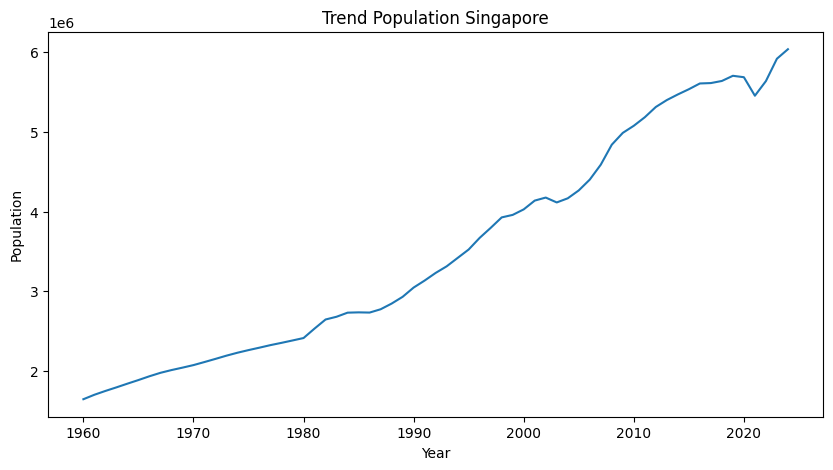

In [82]:
plt.figure(figsize=(10,5))
plt.plot(df_sg['Year'], df_sg['Population'])
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Trend Population Singapore')

img_path = Path("img/")
img_path.mkdir(parents=True, exist_ok=True)
filepath = os.path.join(img_path,"SGP_Trend_Population.png")
plt.savefig(filepath, dpi=600, bbox_inches='tight', facecolor='white')

### 2.2 Plot Growth Rate

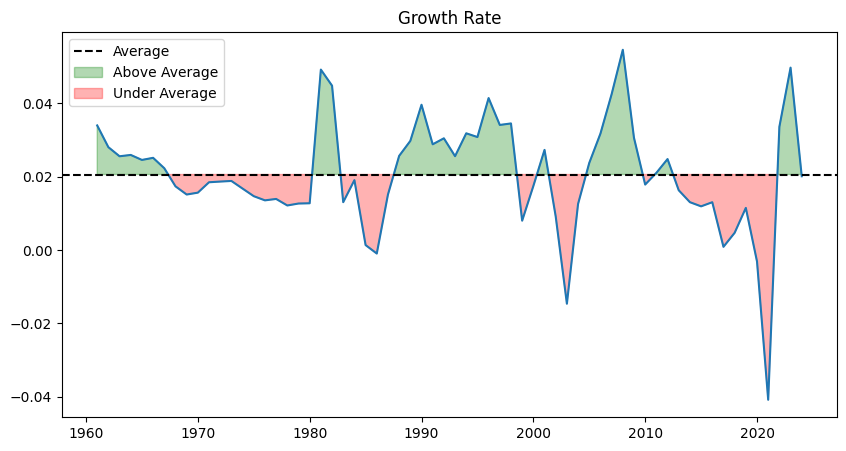

In [83]:
df_sg['Growth'] = df_sg['Population'].pct_change()
avg_growth = df_sg["Growth"].mean()

plt.figure(figsize=(10,5))
plt.plot(df_sg['Year'], df_sg['Growth'])
avg_line = np.full_like(df_sg['Growth'], avg_growth)

plt.axhline(y=avg_growth, color='black', linestyle='--', label='Average')

plt.fill_between(
    df_sg['Year'],
    df_sg['Growth'],
    avg_line,
    where=(df_sg['Growth'] > avg_line),
    interpolate=True,
    alpha=0.3,
    color='green',
    label='Above Average'
)

plt.fill_between(
    df_sg['Year'],
    df_sg['Growth'],
    avg_line,
    where=(df_sg['Growth'] <= avg_line),
    interpolate=True,
    alpha=0.3,
    color='red',
    label='Under Average'
)
plt.title('Growth Rate')
plt.legend()

img_path = Path("img/")
img_path.mkdir(parents=True, exist_ok=True)
filepath = os.path.join(img_path,"Growth_Rate.png")
plt.savefig(filepath, dpi=600, bbox_inches='tight', facecolor='white')

### 2.3 Average Population per Decade

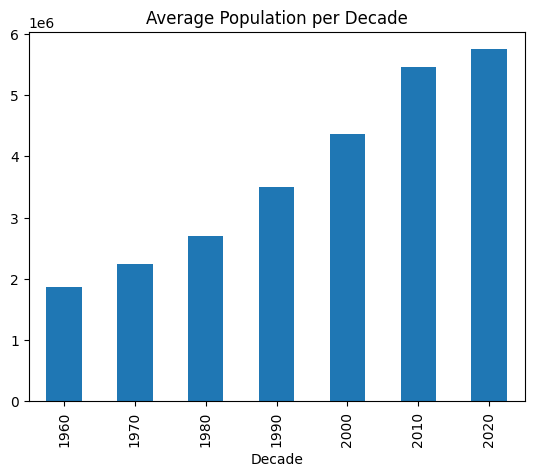

In [84]:
df_sg['Decade'] = (df_sg['Year']//10)*10

df_sg.groupby('Decade')['Population'].mean().plot(kind='bar')
plt.title('Average Population per Decade')

img_path = Path("img/")
img_path.mkdir(parents=True, exist_ok=True)
filepath = os.path.join(img_path,"Average_population_per_decade.png")
plt.savefig(filepath, dpi=600, bbox_inches='tight', facecolor='white')

## 3. Modeling

In [85]:
import numpy as np

X = df_sg['Year'].values.reshape(-1,1)
y = df_sg['Population'].values

### 3.1 Splitting Data

In [86]:
train = df_sg[df_sg['Year'] <= 2019]
test = df_sg[df_sg['Year'] >= 2020]

X_train = train['Year'].values.reshape(-1,1)
y_train = train['Population'].values

X_test = test['Year'].values.reshape(-1,1)
y_test = test['Population'].values

### 3.2 Create Function to Testing different degree

In [87]:
def train_poly_testing_degree(degree):
    poly = PolynomialFeatures(degree=degree)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return model, poly, rmse, r2

### 3.3 Training and plotting (Comparation between degree)

Degree 1 -> RMSE: 152744.31, R2: 0.4576
Degree 2 -> RMSE: 610123.83, R2: -7.6538
Degree 3 -> RMSE: 530008.29, R2: -5.5303
Degree 4 -> RMSE: 528015.21, R2: -5.4813
Degree 5 -> RMSE: 525965.49, R2: -5.4311


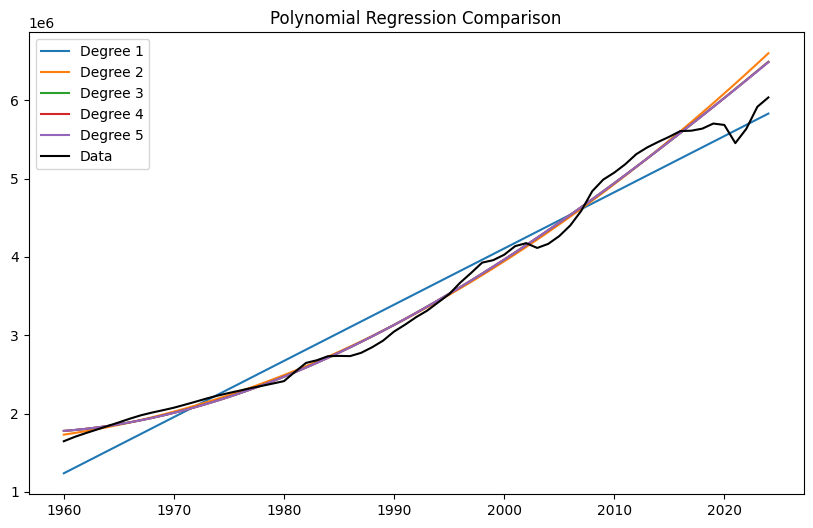

In [88]:
plt.figure(figsize=(10,6))

X_all = df_sg['Year'].values.reshape(-1,1)

for d in range(1, 6):
    model, poly, rmse, r2 = train_poly_testing_degree(d)

    X_all_poly = poly.transform(X_all)
    y_all_pred = model.predict(X_all_poly)

    plt.plot(df_sg['Year'], y_all_pred, label=f'Degree {d}')

    print(f"Degree {d} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

# scatter data asli
plt.plot(df_sg['Year'], df_sg['Population'], color='black', label='Data')

plt.legend()
plt.title('Polynomial Regression Comparison')

img_path = Path("img/")
img_path.mkdir(parents=True, exist_ok=True)
filepath = os.path.join(img_path,"Comparison between degree (1-5).png")
plt.savefig(filepath, dpi=600, bbox_inches='tight', facecolor='white')

In [97]:
best_model = None
best_poly = None
best_rmse = float('inf')
best_degree = None

for d in range(1, 6):
    model, poly, rmse, r2 = train_poly_testing_degree(d)

    print(f"Degree {d} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

    if (rmse < best_rmse) and (r2 > 0):
        best_rmse = rmse
        best_model = model
        best_poly = poly
        best_degree = d
        best_r2 = r2

print(f"\nBest model (degree) : {best_degree}")
print(f"RMSE : {best_rmse}")
print(f"R2 : {best_r2}")

Degree 1 -> RMSE: 152744.31, R2: 0.4576
Degree 2 -> RMSE: 610123.83, R2: -7.6538
Degree 3 -> RMSE: 530008.29, R2: -5.5303
Degree 4 -> RMSE: 528015.21, R2: -5.4813
Degree 5 -> RMSE: 525965.49, R2: -5.4311

Best model (degree) : 1
RMSE : 152744.30527789757
R2 : 0.45762317432995014


## 4. Testing model

In [98]:
X_all = df_sg['Year'].values.reshape(-1,1)
X_all_poly = best_poly.transform(X_all)
y_all_pred = best_model.predict(X_all_poly)

## 4.1 Plotting final model

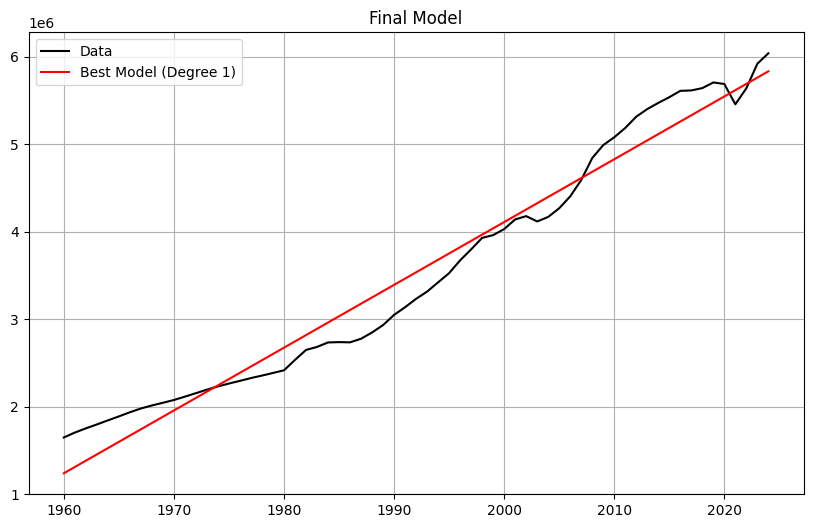

In [105]:
plt.figure(figsize=(10,6))

plt.plot(df_sg['Year'], df_sg['Population'], color='black', label='Data')
plt.plot(df_sg['Year'], y_all_pred, color='red', label=f'Best Model (Degree {best_degree})')

plt.legend()
plt.title('Final Model')
plt.grid()

img_path = Path("img/")
img_path.mkdir(parents=True, exist_ok=True)
filepath = os.path.join(img_path,"Final_model(Degree 1).png")
plt.savefig(filepath, dpi=600, bbox_inches='tight', facecolor='white')

### 4.2 Population prediction for the next 6 years

In [100]:
future_years = np.array([[2025],[2026],[2027],[2028],[2029],[2030]])
future_poly = best_poly.transform(future_years)
future_pred = best_model.predict(future_poly)

In [101]:
for year, pred in zip(future_years.flatten(), future_pred):
    print(f"{year}: {int(pred)}")

2025: 5902404
2026: 5974178
2027: 6045952
2028: 6117727
2029: 6189501
2030: 6261276


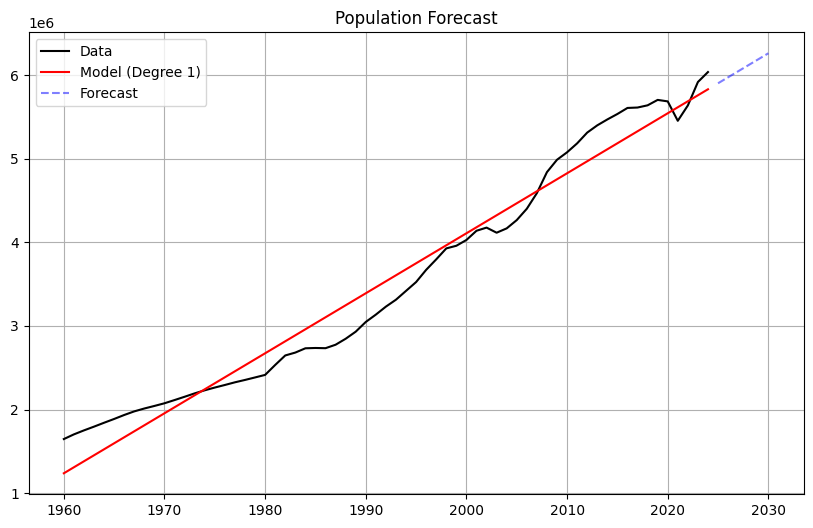

In [107]:
plt.figure(figsize=(10,6))

# data asli
plt.plot(df_sg['Year'], df_sg['Population'], color='black', label='Data')

# model
plt.plot(df_sg['Year'], y_all_pred, color='red', label=f'Model (Degree {best_degree})')

# forecasting
plt.plot(future_years, future_pred, '--', color='blue', label='Forecast', alpha=0.5)

plt.legend()
plt.title('Population Forecast')
plt.grid()

img_path = Path("img/")
img_path.mkdir(parents=True, exist_ok=True)
filepath = os.path.join(img_path,"Forecasting.png")
plt.savefig(filepath, dpi=600, bbox_inches='tight', facecolor='white')